In [1]:
import pandas as pd
import xarray as xr
import numpy as np
import string
from scipy import stats
from scipy.stats import gaussian_kde
from scipy.stats import linregress

import geopandas as gpd

import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
import matplotlib.patches as mpatches
from matplotlib.path import Path
import matplotlib.patheffects as path_effects
from matplotlib.patches import PathPatch
import matplotlib.cm as cm
import matplotlib.colors as colors


import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.io import shapereader
import cartopy.feature as cfeature

import warnings
warnings.filterwarnings('ignore')

In [2]:
def compute_statewise_r2(df, predictor, response="DETRENDED_CRASH_COUNTS"):
    """
    Compute statewise R² and p-value for a linear regression:
    response ~ predictor using scipy.stats.linregress.

    Parameters
    ----------
    df : pd.DataFrame
        Must include 'STATE_ABBR', predictor, and response columns.
    predictor : str
        Column name to use as predictor (e.g. 'NINO34_SST_ANOM').
    response : str, default 'DETRENDED_CRASH_COUNTS'
        Column name to use as response variable.

    Returns
    -------
    pd.DataFrame with STATE_ABBR, R2, pval
    """
    results = []

    for state, g in df.groupby("STATE_ABBR"):
        if len(g) > 1:
            x = g[predictor].values
            y = g[response].values

            slope, intercept, r_value, p_value, std_err = linregress(x, y)

            results.append({
                "STATE_ABBR": state,
                "R2": r_value**2,
                "pval": p_value
            })
        else:
            results.append({"STATE_ABBR": state, "R2": float("nan"), "pval": float("nan")})

    return pd.DataFrame(results)


In [ ]:
def plot_crash_anomalies(df,col_sel='ANOM_CRASH_COUNTS'):
    color_pos = '#D55E00'  # orange
    color_neg = '#0072B2'  # blue
    panel_bg = '#f7f7f7'   # light gray background
    font_size = 14

    # Filter for national anomalies
    anomalies = df[df['STATE_ABBR'] == 'USA'].copy()
    dates = anomalies['DATE']
    values = anomalies[col_sel]

    fig, ax = plt.subplots(figsize=(18, 6))
    
    # Plot black line
    ax.plot(dates, values, color='black', linewidth=1.5, alpha=0.3, label='_nolegend_')

    # Positive and negative masks
    mask_pos = values >= 0
    mask_neg = values < 0

    # Fill positive and negative areas
    ax.fill_between(dates, 0, values, where=mask_pos,
                    facecolor=color_pos, alpha=0.6, interpolate=True, label='Positive Anomaly')
    ax.fill_between(dates, 0, values, where=mask_neg,
                    facecolor=color_neg, alpha=0.6, interpolate=True, label='Negative Anomaly')

    # Title and labels
    ax.set_title('Monthly Fatal Crash Anomalies (1981–2019)', fontsize=font_size + 4, fontweight='bold', pad=15)
    ax.set_ylabel('Crash Anomaly', fontsize=font_size + 1, fontweight='bold')
    ax.set_xlabel('Time', fontsize=font_size + 1, fontweight='bold')

    # X ticks every year
    years = dates.dt.year.unique()
    year_start_indices = [dates[dates.dt.year == y].index[0] for y in years]
    ax.set_xticks(dates[year_start_indices])
    ax.set_xticklabels(years, rotation=45, ha='right', fontsize=font_size, fontweight='bold')

    ax.axhline(0, color='gray', linewidth=1, linestyle='--')

    # Bold spines
    for spine in ax.spines.values():
        spine.set_linewidth(2)

    # Bold ticks
    ax.tick_params(axis='both', which='major', labelsize=font_size, width=1.5, length=6)

    # Grid lines on y axis
    ax.grid(axis='y', linestyle=':', alpha=0.4)

    ax.legend(fontsize=font_size, frameon=False, loc='upper right')

    plt.tight_layout(pad=2.5)
    plt.savefig('../figs/Crash_Anomalies.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()


In [4]:
def plot_nino34(df, col_sel='NINO34_SST_ANOM'):

    df = df.copy()
    
    df['DATE'] = pd.to_datetime(df[['YEAR','MONTH']].assign(DAY=1))
    
    # drop duplicates if multiple states per month
    df = df.drop_duplicates(subset=['YEAR','MONTH'])

    # sort by date
    df = df.sort_values('DATE')

    df['DATE'] = pd.to_datetime(df[['YEAR', 'MONTH']].assign(DAY=1))
    dates = df['DATE']
    line_values = df[col_sel].values

    color_pos = '#D55E00'
    color_neg = '#0072B2'

    fig, ax = plt.subplots(figsize=(16,6))
    ax.plot(dates, line_values, color='black', linewidth=2, alpha=0.7)

    # Positive anomalies (El Nino)
    pos_values = np.clip(line_values, 0.5, None)  # clip below 0.5
    mask_pos = line_values >= 0.5
    ax.fill_between(dates, 0.5, pos_values, where=mask_pos, color=color_pos, alpha=0.7,
                    label='El Niño ≥ 0.5°C')

    # Negative anomalies (La Nina)
    neg_values = np.clip(line_values, None, -0.5)  # clip above -0.5
    mask_neg = line_values <= -0.5
    ax.fill_between(dates, neg_values, -0.5, where=mask_neg, color=color_neg, alpha=0.7,
                    label='La Niña ≤ -0.5°C')

    # Threshold lines
    ax.axhline(0, color='black', linewidth=1)
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8)
    ax.axhline(-0.5, color='gray', linestyle='--', linewidth=0.8)

    ax.set_title('Monthly NINO3.4 SST Anomalies (1981–2019)', fontsize=18, fontweight='bold')
    ax.set_xlabel('Time', fontsize=16, fontweight='bold')
    ax.set_ylabel('SST Anomalies (°C)', fontsize=16, fontweight='bold')

    fig.autofmt_xdate(rotation=45)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.legend(fontsize=12, frameon=False)
    plt.tight_layout()
    plt.show()


In [5]:
def plot_state_precip_anomalies(df, state_centers=None):
    """
    Plot continental US state-level mean precipitation anomalies for
    El Nino and La Nina regimes using monthly_summary DataFrame.

    Parameters
    ----------
    df : pd.DataFrame
        Must contain columns ['STATE_ABBR', 'NINO34_SST_ANOM', 'PRECIP_ANOM_MEAN'].
    state_centers : dict
        Dictionary mapping STATE_ABBR to (lon, lat) for label placement.

    Notes
    -----
    Produces two portrait panels: La Nina (top), El Nino (bottom),
    with anomaly values labeled on each state and colorbar below panels.
    """
    if state_centers is None:
        raise ValueError("state_centers dictionary must be provided")

    # Load continental US states
    shpfilename = shapereader.natural_earth('50m', 'cultural', 'admin_1_states_provinces_lakes')
    gdf_states = gpd.read_file(shpfilename)
    continental = gdf_states[~gdf_states['postal'].isin(['AK', 'HI', 'PR'])].copy()
    continental = continental.rename(columns={'postal':'STATE_ABBR'})

    # Assign regime
    df_plot = df.copy()
    df_plot['REGIME'] = pd.NA
    df_plot.loc[df_plot['NINO34_SST_ANOM'] >= 0.5, 'REGIME'] = 'El Nino'
    df_plot.loc[df_plot['NINO34_SST_ANOM'] <= -0.5, 'REGIME'] = 'La Nina'

    # Aggregate mean precipitation anomaly by state and regime
    df_state_summary = (
        df_plot.dropna(subset=['REGIME'])
               .groupby(['STATE_ABBR','REGIME'], as_index=False)
               .agg({'PRECIP_ANOM_MEAN':'mean'})
               .rename(columns={'PRECIP_ANOM_MEAN':'ANOMALY'})
    )

    # Merge with state geometries
    gdf_plot = continental.merge(df_state_summary, on='STATE_ABBR', how='left')

    # Plot
    fig, axes = plt.subplots(2, 1, figsize=(8, 14),
                             subplot_kw={'projection': ccrs.PlateCarree()})
    regimes = ['La Nina','El Nino']
    cmap = 'BrBG'
    abs_max = max(abs(gdf_plot['ANOMALY'].min()), gdf_plot['ANOMALY'].max())
    norm = mcolors.TwoSlopeNorm(vmin=-abs_max, vcenter=0, vmax=abs_max)

    for ax, regime in zip(axes, regimes):
        ax.set_extent([-125, -66.5, 24, 50], ccrs.PlateCarree())
        ax.add_feature(cartopy.feature.COASTLINE, linewidth=0.5)
        ax.add_feature(cartopy.feature.BORDERS, linewidth=0.3)
        ax.add_feature(cartopy.feature.STATES, edgecolor='gray', linewidth=0.3)

        subset = gdf_plot[gdf_plot['REGIME']==regime]
        subset.plot(column='ANOMALY', cmap=cmap, norm=norm, linewidth=0.5,
                    edgecolor='black', ax=ax, transform=ccrs.PlateCarree())

        # Label states with anomaly values
        for _, row in subset.iterrows():
            x, y = state_centers.get(row['STATE_ABBR'], (None, None))
            if x and y and not pd.isna(row['ANOMALY']):
                ax.text(x, y, f"{row['ANOMALY']:.2f}", ha='center', va='center',
                        fontsize=8, fontweight='bold')

        ax.set_title(f"{regime}", fontsize=14, fontweight='bold')

    # Colorbar below panels
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm._A = []
    cbar_ax = fig.add_axes([0.15, 0.05, 0.7, 0.02])
    cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
    cbar.set_label("Mean Precipitation Anomaly (mm/day)", fontweight='bold')

    plt.tight_layout(rect=[0,0.1,1,1])
    plt.show()


In [6]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.io import shapereader
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
import numpy as np

def plot_state_r2(r2_df, state_centers, title="R² Map", filename=None, cmap='Greens', clim=(0,1)):
    """
    Plot a US map of R² values per state with significant states marked.
    
    Parameters:
    - r2_df: DataFrame with columns ['STATE_ABBR','R2','significant']
    - state_centers: dict mapping state abbreviation -> (lon, lat) for labeling
    - title: figure title
    - filename: if provided, save figure to this path
    - cmap: matplotlib colormap
    - clim: tuple for color limits (vmin, vmax)
    """
    fig, ax = plt.subplots(1, 1, figsize=(12,8), subplot_kw={'projection': ccrs.PlateCarree()})
    ax.set_extent([-125, -66, 24, 50])
    ax.add_feature(cfeature.LAND, facecolor='#f0f0f0')
    ax.add_feature(cfeature.OCEAN, facecolor='#d0e0ff')
    ax.add_feature(cfeature.STATES, edgecolor='gray', linewidth=1)
    
    # Load US state geometries
    shp = shapereader.natural_earth('50m', 'cultural', 'admin_1_states_provinces')
    
    patches, values = [], []

    for state in shapereader.Reader(shp).records():
        abbr = state.attributes['postal']
        row = r2_df[r2_df['STATE_ABBR'] == abbr]
        if row.empty:
            continue
        r2_val = row.iloc[0]['R2']
        geom = state.geometry
        polys = [geom] if geom.geom_type == 'Polygon' else geom.geoms
        for poly in polys:
            poly_patch = Polygon(list(poly.exterior.coords), closed=True)
            patches.append(poly_patch)
            values.append(r2_val)

    # Plot R² values as color map
    pc = PatchCollection(patches, cmap=cmap, edgecolor='gray', linewidth=1)
    pc.set_array(np.array(values))
    pc.set_clim(*clim)
    ax.add_collection(pc)
    
    # Add state labels and significance markers
    for _, row in r2_df.iterrows():
        abbr = row['STATE_ABBR']
        if abbr in state_centers:
            lon, lat = state_centers[abbr]
            ax.text(lon, lat, f"{abbr}\n{row['R2']:.2f}",
                    ha='center', va='center', fontsize=8,
                    bbox=dict(facecolor='white', alpha=0.7, boxstyle='round,pad=0.2'))
            if row['significant']:
                ax.plot(lon, lat, marker='*', color='red', markersize=10, transform=ccrs.PlateCarree())

    cbar = fig.colorbar(pc, ax=ax, orientation='horizontal', fraction=0.035, pad=0.03, extend='max')
    cbar.set_label('R² Value', fontsize=12)
    
    ax.set_title(title, fontsize=14, weight='bold')
    plt.tight_layout()
    
    if filename:
        fig.savefig(filename, dpi=300, bbox_inches='tight')
    
    plt.show()


def plot_state_r2(df, state_centers=None):
    """
    Plot statewise R² values on a US map.

    Parameters
    ----------
    df : pd.DataFrame
        Must contain columns ['STATE_ABBR', 'R2'].
    state_centers : dict
        Mapping of state abbreviations -> (lon, lat) for labels.
    """
    if state_centers is None:
        raise ValueError("state_centers dictionary must be provided")

    # Load continental US states
    shpfilename = shapereader.natural_earth(
        resolution='50m', category='cultural',
        name='admin_1_states_provinces_lakes'
    )
    gdf_states = gpd.read_file(shpfilename)
    continental = gdf_states[~gdf_states['postal'].isin(['AK', 'HI', 'PR'])].copy()
    continental = continental.rename(columns={'postal': 'STATE_ABBR'})

    # Merge with R² values
    gdf_plot = continental.merge(df, on='STATE_ABBR', how='left')

    # Set up plot
    fig, ax = plt.subplots(
        1, 1, figsize=(8, 6),
        subplot_kw={'projection': ccrs.PlateCarree()}
    )

    cmap = "YlGnBu"  # sequential colormap
    vmin, vmax = 0, 1  # R² range
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    ax.set_extent([-125, -66.5, 24, 50], ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    ax.add_feature(cfeature.STATES, edgecolor='gray', linewidth=0.3)

    # Plot states colored by R²
    gdf_plot.plot(
        column='R2', cmap=cmap,
        linewidth=0.5, edgecolor='black',
        ax=ax, transform=ccrs.PlateCarree()
    )

    # Add labels
    for _, row in gdf_plot.iterrows():
        x, y = state_centers.get(row['STATE_ABBR'], (None, None))
        if x and y and not pd.isna(row['R2']):
            ax.text(
                x, y, f"{row['R2']:.2f}",
                ha='center', va='center',
                fontsize=8, fontweight='bold'
            )

    # Colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm._A = []
    cbar_ax = fig.add_axes([0.15, 0.05, 0.7, 0.02])
    cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
    cbar.set_label("R-squared FWRCA and Predictor", fontweight='bold')

    plt.subplots_adjust(bottom=0.15)
    plt.show()

In [7]:
def plot_cluster_composites(cluster_comp, cmap='RdBu_r', lon_0=260,
                             suptitle="ERA5 Z500 Anomalies DJF 1981–2019", 
                             nrows=2, ncols=2, levels=np.arange(-90, 100, 10),
                             save_path=None, dpi=300):

    fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(8.5, 11.0),
                            subplot_kw={'projection': ccrs.NorthPolarStereo(central_longitude=lon_0)})

    axs = axs.flatten()
    titles = cluster_comp['names'].values
    freq=cluster_comp['freq'].values
    k = 0

    # Create circular Path in Axes coordinates
    theta = np.linspace(0, 2 * np.pi, 100)
    circle_x = 0.5 + 0.5 * np.cos(theta)
    circle_y = 0.5 + 0.5 * np.sin(theta)
    circle_path = Path(np.column_stack([circle_x, circle_y]))

    for ax, label in zip(axs, string.ascii_lowercase):
        # Apply circular boundary using Path
        ax.set_boundary(circle_path, transform=ax.transAxes)

        ax.set_extent([-180, 180, 10, 90], crs=ccrs.PlateCarree())
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
        ax.add_feature(cfeature.BORDERS, linewidth=0.3)
        #ax.gridlines(draw_labels=False)

        cs = ax.contourf(cluster_comp['lon'].values,
                         cluster_comp['lat'].values,
                         cluster_comp['z'][k, :, :].values,
                         levels=levels,
                         cmap=cmap,
                         extend='both',
                         transform=ccrs.PlateCarree())

        title_text = f"({label}) {titles[k]} ({freq[k]}%)" if freq is not None else titles[k]
        ax.set_title(title_text, loc='center', fontsize='medium', fontweight='bold')
#        ax.text(0.01, 0.99, f"({label})", transform=ax.transAxes,
#                ha='left', va='top', fontsize='large', fontweight='bold')
        k += 1

    # fig.subplots_adjust(bottom=0.1, top=0.92, hspace=0.25)
    fig.subplots_adjust(bottom=0.25, top=0.92, hspace=0.05)
    cbar_ax = fig.add_axes([0.25, 0.2, 0.5, 0.02])
    cbar = fig.colorbar(cs, cax=cbar_ax, orientation='horizontal')
    cbar.set_label("m")

    fig.suptitle(suptitle, fontsize='x-large')

    if save_path is not None:
        fig.savefig(save_path, dpi=dpi, bbox_inches='tight')

    plt.show()

In [8]:
def plot_precip_cluster_composites(cluster_pcomp, titles=None,cmap='BrBG', lon_0=260,
                                    suptitle="CHIRPS Global Precip Anomalies DJF 1981–2019",
                                    nrows=2, ncols=2, levels=np.arange(-1, 1.2, 0.2),
                                    extent=[225, 300, 20, 50],
                                    save_path=None, dpi=300):

    fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(11.0,8.5),
                            subplot_kw={'projection': ccrs.PlateCarree(central_longitude=lon_0)})
    axs = axs.flatten()
    k = 0

    for ax, label in zip(axs, string.ascii_lowercase):
        # Set map extent
        ax.set_extent(extent, crs=ccrs.PlateCarree())

        # Add features
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
        ax.add_feature(cfeature.BORDERS, linewidth=0.3)
        ax.add_feature(cfeature.STATES, edgecolor='gray', linewidth=0.3)

        # Filled contour plot
        cs = ax.contourf(cluster_pcomp['lon'].values,
                         cluster_pcomp['lat'].values,
                         cluster_pcomp['precip'][k, :, :].values,
                         levels=levels,
                         cmap=cmap,
                         extend='both',
                         transform=ccrs.PlateCarree())

        # Title with subplot label
        ax.set_title(f"({label}) {titles[k]}", loc='center', fontsize='medium', fontweight='bold')
        k += 1

    # Adjust spacing and add colorbar
    fig.subplots_adjust(bottom=0.25, top=0.90, hspace=0.15)
    cbar_ax = fig.add_axes([0.25, 0.2, 0.5, 0.02])
    cbar = fig.colorbar(cs, cax=cbar_ax, orientation='horizontal')
    cbar.set_label("mm/day", fontweight='bold')

    # Super title
    #fig.suptitle(suptitle, fontsize='x-large', fontweight='bold')

    # Save or show
    if save_path is not None:
        fig.savefig(save_path, dpi=dpi, bbox_inches='tight')

    plt.show()


In [9]:
def plot_wxregimes_state_precip_anomalies(df, state_centers=None):
    """

    Parameters
    ----------
    df : pd.DataFrame
        Must contain columns ['STATE_ABBR', 'NINO34_SST_ANOM', 'PRECIP_ANOM_MEAN'].
    state_centers : dict
        Dictionary mapping STATE_ABBR to (lon, lat) for label placement.

    Notes
    -----
    Produces two portrait panels: La Nina (top), El Nino (bottom),
    with anomaly values labeled on each state and colorbar below panels.
    """
    if state_centers is None:
        raise ValueError("state_centers dictionary must be provided")

    # Load continental US states
    shpfilename = shapereader.natural_earth('50m', 'cultural', 'admin_1_states_provinces_lakes')
    gdf_states = gpd.read_file(shpfilename)
    continental = gdf_states[~gdf_states['postal'].isin(['AK', 'HI', 'PR'])].copy()
    continental = continental.rename(columns={'postal':'STATE_ABBR'})

    # Assign regime
    df_plot = df.copy()

    # Aggregate mean precipitation anomaly by state and regime
    df_state_summary = (
        df_plot.dropna(subset=['cluster'])
               .groupby(['STATE_ABBR','cluster'], as_index=False)
               .agg({'ANOM_MEAN':'mean'})
               .rename(columns={'ANOM_MEAN':'ANOMALY'})
    )

    # Merge with state geometries
    gdf_plot = continental.merge(df_state_summary, on='STATE_ABBR', how='left')

    # Plot
    fig, axes = plt.subplots(2, 2, figsize=(11,8.5),
                             subplot_kw={'projection': ccrs.PlateCarree()})
    axes = axes.flatten()

    regimes = df_plot['cluster'].unique()
    cmap = 'BrBG'
    abs_max = max(abs(gdf_plot['ANOMALY'].min()), gdf_plot['ANOMALY'].max())
    norm = mcolors.TwoSlopeNorm(vmin=-abs_max, vcenter=0, vmax=abs_max)

    for ax, regime in zip(axes, regimes):
        ax.set_extent([-125, -66.5, 24, 50], ccrs.PlateCarree())
        ax.add_feature(cartopy.feature.COASTLINE, linewidth=0.5)
        ax.add_feature(cartopy.feature.BORDERS, linewidth=0.3)
        ax.add_feature(cartopy.feature.STATES, edgecolor='gray', linewidth=0.3)

        subset = gdf_plot[gdf_plot['cluster']==regime]
        subset.plot(column='ANOMALY', cmap=cmap, norm=norm, linewidth=0.5,
                    edgecolor='black', ax=ax, transform=ccrs.PlateCarree())

        # Label states with anomaly values
        for _, row in subset.iterrows():
            x, y = state_centers.get(row['STATE_ABBR'], (None, None))
            if x and y and not pd.isna(row['ANOMALY']):
                ax.text(x, y, f"{row['ANOMALY']:.2f}", ha='center', va='center',
                        fontsize=8, fontweight='bold')

        ax.set_title(f"{regime}", fontsize=14, fontweight='bold')

    # Colorbar below panels
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm._A = []
    cbar_ax = fig.add_axes([0.15, 0.05, 0.7, 0.02])
    cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
    cbar.set_label("Mean Precipitation Anomaly (mm/day)", fontweight='bold')

    plt.tight_layout(rect=[0,0.1,1,1])
    plt.show()


def plot_statewise_precip_anomalies(
    gdf_precip, regime_names=None,
    cmap='BrBG',
    suptitle="State-Level Precip Anomalies by Regime (DJF 1981–2019)",
    extent=[-125, -66.5, 24, 50],
    nrows=2, ncols=2,
    save_path=None, dpi=300):

    # Set up color range based on data
    abs_max = np.nanmax(np.abs(gdf_precip['ANOMALY']))
    norm = mcolors.Normalize(vmin=-abs_max, vmax=abs_max)
    cmap = cm.get_cmap(cmap)

    fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 9),
                            subplot_kw={'projection': ccrs.PlateCarree()})
    axs = axs.flatten()

    regimes = sorted(gdf_precip['REGIME'].dropna().unique())

    for i, (regime, ax) in enumerate(zip(regimes, axs)):
        ax.set_extent(extent, crs=ccrs.PlateCarree())

        # Add features
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
        ax.add_feature(cfeature.BORDERS, linewidth=0.3)
        ax.add_feature(cfeature.STATES, edgecolor='gray', linewidth=0.3)

        subset = gdf_precip[gdf_precip['REGIME'] == regime]

        # Plot filled states
        subset.plot(column='ANOMALY',
                    cmap=cmap,
                    norm=norm,
                    linewidth=0.5,
                    edgecolor='black',
                    ax=ax,
                    transform=ccrs.PlateCarree())

        label = regime_names.get(regime, f"Regime {regime}") if regime_names else f"Regime {regime}"
        ax.set_title(f"({string.ascii_lowercase[i]}) {label}", fontsize='medium', fontweight='bold')

    # Colorbar
    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    sm._A = []  # required for older matplotlib

    fig.subplots_adjust(bottom=0.15, top=0.92, hspace=0.2)
    cbar_ax = fig.add_axes([0.25, 0.08, 0.5, 0.02])
    cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
    cbar.set_label("Precip Anomaly (mm/day)", fontweight='bold')

    # Super title
    fig.suptitle(suptitle, fontsize=16, fontweight='bold')

    if save_path:
        fig.savefig(save_path, dpi=dpi, bbox_inches='tight')

    plt.show()


def plot_enso_anomaly_maps(el_nino_avgs, la_nina_avgs, state_centers, save_path='../figs/enso_precip_anomalies.png'):

    fig, axes = plt.subplots(nrows=2, figsize=(8.5, 11), subplot_kw={'projection': ccrs.PlateCarree()})

    cmap = plt.cm.BrBG
    vmin, vmax = -0.5, 0.5
    norm = plt.Normalize(vmin=vmin, vmax=vmax)

    titles = ['a) El Niño', 'b) La Niña']
    data_dicts = [el_nino_avgs, la_nina_avgs]

    shpfilename = shapereader.natural_earth(resolution='50m',
                                            category='cultural',
                                            name='admin_1_states_provinces_lakes')
    reader = shapereader.Reader(shpfilename)
    states = list(reader.records())
    
    
    for ax, title, data in zip(axes, titles, data_dicts):
        ax.set_extent([-125, -66, 24, 50], crs=ccrs.PlateCarree())
        ax.add_feature(cfeature.LAND, facecolor='#f0f0f0')
        ax.add_feature(cfeature.OCEAN, facecolor='#d0e0ff')
        ax.add_feature(cfeature.STATES, linewidth=1.2, edgecolor='gray')

        patches = []
        values = []

        for state in states:
            abbrev = state.attributes['postal']
            if abbrev in data:
                geom = state.geometry
                if geom.geom_type == 'Polygon':
                    polygons = [geom]
                elif geom.geom_type == 'MultiPolygon':
                    polygons = list(geom.geoms)
                else:
                    continue
                for polygon in polygons:
                    patches.append(Polygon(np.array(polygon.exterior.coords.xy).T))
                    values.append(data[abbrev])

        pc = PatchCollection(patches, cmap=cmap, norm=norm, edgecolor='gray', linewidth=1.2)
        pc.set_array(np.array(values))
        ax.add_collection(pc)

        for state, value in data.items():            
            if state in state_centers:
                
                lon, lat = state_centers[state]
                ax.text(lon, lat, f"{state}\n{value:.2f}", ha='center', va='center',
                        fontsize=8, bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.2'))

        ax.set_title(title, fontsize=14, fontweight='bold', pad=12)

    # Shared colorbar at bottom
    #sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    #sm.set_array([])
    #cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), orientation='horizontal',
    #                    fraction=0.04, pad=0.05)
    #cbar.set_label('Precipitation Anomaly (mm/day)', fontsize=14)
    
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(
        sm,
        ax=axes.ravel().tolist(),
        orientation='horizontal',
        fraction=0.04,
        pad=0.07,
        extend='both'  # <-- enables arrows at both ends
    )    
    cbar.set_label('Precipitation Anomaly (mm/day)', fontsize=14)
    #plt.tight_layout(rect=[0, 0.03, 1, 0.97])
    plt.subplots_adjust(left=0.07, right=0.97, top=0.97, bottom=0.2, hspace=0.08)    
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


def plot_swe_anomaly_maps(el_nino_avgs, la_nina_avgs, state_centers, save_path='swe_anomalies_enso.png'):
 
    # Setup
    fig, axes = plt.subplots(nrows=2, figsize=(8.5, 11), subplot_kw={'projection': ccrs.PlateCarree()})
    titles = ['a) El Niño', 'b) La Niña']
    data_dicts = [el_nino_avgs, la_nina_avgs]

    cmap = plt.cm.BrBG
    vmin, vmax = -0.01, 0.01
    norm = plt.Normalize(vmin=vmin, vmax=vmax)

    # Shapefile
    shpfilename = shapereader.natural_earth(resolution='50m',
                                            category='cultural',
                                            name='admin_1_states_provinces_lakes')
    reader = shapereader.Reader(shpfilename)
    states = list(reader.records())

    for ax, title, data in zip(axes, titles, data_dicts):
        ax.set_extent([-125, -66, 24, 50])
        ax.add_feature(cfeature.LAND, facecolor='#f0f0f0')
        ax.add_feature(cfeature.OCEAN, facecolor='#d0e0ff')
        ax.add_feature(cfeature.STATES, linewidth=1.2, edgecolor='gray')

        patches, values = [], []
        for state in states:
            abbrev = state.attributes['postal']
            if abbrev in data:
                geom = state.geometry
                polygons = [geom] if geom.geom_type == 'Polygon' else list(geom.geoms)
                for polygon in polygons:
                    coords = np.array(polygon.exterior.coords.xy).T
                    patches.append(Polygon(coords))
                    values.append(data[abbrev])

        pc = PatchCollection(patches, cmap=cmap, norm=norm, edgecolor='gray', linewidth=1.2)
        pc.set_array(np.array(values))
        ax.add_collection(pc)

        # Add text labels
        for state, value in data.items():
            if state in state_centers:
                lon, lat = state_centers[state]
                ax.text(lon, lat, f"{state}\n{float(value):.3f}",
                        ha='center', va='center', fontsize=8,
                        bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.2'))

        ax.set_title(title, fontsize=14, fontweight='bold', pad=10)

    # Shared colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), orientation='horizontal',
                        fraction=0.04, pad=0.07, extend='both')
    cbar.set_label('SWE Anomaly (mm)', fontsize=14, fontweight='bold')
    cbar.ax.tick_params(labelsize=12)

    # Layout
    plt.subplots_adjust(left=0.06, right=0.96, top=0.96, bottom=0.2, hspace=0.12)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


def compute_r2_significance(df, r2_col='R_Squared', n=39):
    df = df.copy()
    df['Correlation'] = np.sign(df[r2_col]) * np.sqrt(np.abs(df[r2_col]))
    df['t_stat'] = df['Correlation'] * np.sqrt((n - 2) / (1 - df['Correlation']**2))
    df['p_value'] = 2 * (1 - stats.t.cdf(np.abs(df['t_stat']), df=n - 2))
    df['significant_0.05'] = df['p_value'] < 0.05
    return df


def plot_r2_map_panels(results_df, state_centers, filename_base="fwrca_r2"):

    def draw_map(ax, var, col, title, results_df):
        ax.set_extent([-125, -66, 24, 50])
        ax.add_feature(cfeature.LAND, facecolor='#f0f0f0')
        ax.add_feature(cfeature.OCEAN, facecolor='#d0e0ff')
        ax.add_feature(cfeature.STATES, edgecolor='gray', linewidth=1)

        patches, values, sig_patches = [], [], []
        shp = shapereader.natural_earth('50m', 'cultural', 'admin_1_states_provinces')

        for state in shapereader.Reader(shp).records():
            abbr = state.attributes['postal']
            row = results_df[(results_df['State'] == abbr) & (results_df['Variable'] == var)]
            if row.empty:
                continue

            r2 = row.iloc[0][col]
            pval = row.iloc[0]['P_Value_ENSO'] if "ENSO" in col else row.iloc[0]['P_Value_Total']

            geom = state.geometry
            polys = [geom] if geom.geom_type == 'Polygon' else geom.geoms

            for poly in polys:
                coords = list(poly.exterior.coords)
                poly_patch = Polygon(coords, closed=True)
                patches.append(poly_patch)
                values.append(r2)
                if pval < 0.05:
                    sig_patches.append(poly_patch)

        pc = PatchCollection(patches, cmap='Greens', edgecolor='gray', linewidth=1)
        pc.set_array(np.array(values))
        pc.set_clim(0.1, 0.5)
        ax.add_collection(pc)

        for _, row in results_df[results_df['Variable'] == var].iterrows():
            abbr = row['State']
            if abbr in state_centers:
                lon, lat = state_centers[abbr]
                r2_val = row[col]
                #sig_marker = "*" if (row['P_Value_ENSO'] if "ENSO" in col else row['P_Value_Total']) < 0.05 else ""
                ax.text(lon, lat, f"{abbr}\n{r2_val:.2f}",
                        ha='center', va='center', fontsize=8,
                        bbox=dict(facecolor='white', alpha=0.7, boxstyle='round,pad=0.2'))

        ax.set_title(title, fontsize=13, weight='bold')
        return pc

    def make_figure(rows):
        fig, axs = plt.subplots(2, 1, figsize=(8.5, 11), subplot_kw={'projection': ccrs.PlateCarree()})
        pcs = []
        for ax, (var, col, title) in zip(axs, rows):
            pc = draw_map(ax, var, col, title, results_df)
            pcs.append(pc)
        return fig, axs, pcs[-1]

    # === Total anomalies figure ===
    rows_total = [
        ('Precip', 'R_Squared_Total', "a): Total Precip Anomaly vs FWRCA"),
        ('SWE',    'R_Squared_Total', "b): Total SWE Anomaly vs FWRCA")
    ]
    fig1, axs1, pc1 = make_figure(rows_total)
#    fig1.suptitle("Total Anomalies vs FWRCA", fontsize=16, weight='bold')
    cbar = fig1.colorbar(pc1, ax=axs1.ravel().tolist(), orientation='horizontal', fraction=0.035, pad=0.03, extend='max')
    cbar.set_label('R² Value', fontsize=13)
    plt.tight_layout()
    plt.subplots_adjust(top=0.93, bottom=0.15)
    fig1.savefig(f"{filename_base}_total_2x1.png", dpi=300, bbox_inches='tight')

    # === ENSO-only anomalies figure ===
    rows_enso = [
        ('Precip', 'R_Squared_ENSO', "a) ENSO Precip Anomaly vs FWRCA"),
        ('SWE',    'R_Squared_ENSO', "b) ENSO SWE Anomaly vs FWRCA")
    ]
    fig2, axs2, pc2 = make_figure(rows_enso)
#    fig2.suptitle("ENSO-Precip Anomalies vs FWRCA", fontsize=16, weight='bold')
    cbar2 = fig2.colorbar(pc2, ax=axs2.ravel().tolist(), orientation='horizontal', fraction=0.035, pad=0.03, extend='max')
    cbar2.set_label('R² Value', fontsize=13)
    plt.tight_layout()
    plt.subplots_adjust(top=0.93, bottom=0.15)
    fig2.savefig(f"{filename_base}_enso_only_2x1.png", dpi=300, bbox_inches='tight')

    plt.show()


def compute_statewise_regime_anomalies(df_fars, ds_cd, ds_comp, regime_months=[12, 1, 2], decorr_time=28):
    df_fars = df_fars.copy()
    df_fars['DATE'] = pd.to_datetime(df_fars[['YEAR', 'MONTH', 'DAY']], errors='coerce')
    df_fars['STATE'] = df_fars['STATE'].astype(str).str.zfill(2)

    daily_by_state = df_fars.groupby(['STATE', 'DATE']).size().reset_index(name='CRASH_COUNT')
    daily_by_state['DOY'] = daily_by_state['DATE'].dt.dayofyear
    clim = daily_by_state.groupby(['STATE', 'DOY'])['CRASH_COUNT'].mean().reset_index(name='CLIM_MEAN')
    daily_by_state = daily_by_state.merge(clim, on=['STATE', 'DOY'])
    daily_by_state['CRASH_ANOMALY'] = daily_by_state['CRASH_COUNT'] - daily_by_state['CLIM_MEAN']

    filtered_ds = ds_cd.sel(time=ds_cd['time.month'].isin(regime_months))
    df_clusters = filtered_ds[['cluster']].to_dataframe().reset_index()
    df_clusters.rename(columns={'time': 'DATE', 'cluster': 'REGIME'}, inplace=True)
    df_clusters['DATE'] = pd.to_datetime(df_clusters['DATE'])
    df_clusters['REGIME'] = df_clusters['REGIME'].astype(int)

    merged = daily_by_state.merge(df_clusters[['DATE', 'REGIME']], on='DATE', how='inner')
    mean_by_regime_state = merged.groupby(['REGIME', 'STATE'])['CRASH_ANOMALY'].mean().reset_index()

    counts = merged.groupby(['REGIME', 'STATE']).size()
    effective_n = (counts / decorr_time).astype(int)
    ci_dict = {}
    for (reg, state), group_df in merged.groupby(['REGIME', 'STATE']):
        sample = group_df['CRASH_ANOMALY'].dropna()
        sem = sample.sem()
        dfree = effective_n.get((reg, state), 0) - 1
        ci_dict[(reg, state)] = stats.t.ppf(0.975, df=dfree) * sem if dfree > 0 else np.nan

    mean_by_regime_state['CI'] = mean_by_regime_state.apply(
        lambda row: ci_dict.get((row['REGIME'], row['STATE']), np.nan), axis=1
    )
    if 'names' in ds_comp:
        regime_names = {i: str(name.values) for i, name in enumerate(ds_comp['names'])}
        mean_by_regime_state['REGIME_NAME'] = mean_by_regime_state['REGIME'].map(regime_names)

    return mean_by_regime_state


def compute_statewise_regime_anomalies_pct(df_fars, ds_cd, ds_comp, states_map):
    """
    Compute mean crash anomaly as percent of total crashes in each state by weather regime.

    Parameters:
    - df_fars: DataFrame with columns ['YEAR', 'MONTH', 'DAY', 'STATE'] representing crash records
    - ds_cd: xarray Dataset/DataArray with daily regime cluster assignment ('cluster'), time coordinate
    - ds_comp: Dataset or object with regime names in ds_comp['names']
    - states_map: GeoDataFrame with US states polygons, with 'STATEFP' column as state FIPS codes

    Returns:
    - gdf_pct: GeoDataFrame merging states_map with percent anomalies by state and regime,
      columns: ['STATEFP', 'REGIME', 'ANOMALY_PCT', 'geometry', ...]
    """
    import scipy.stats as stats

    # 1. Prepare df_fars with datetime
    df_fars = df_fars.copy()
    df_fars['DATE'] = pd.to_datetime(df_fars[['YEAR', 'MONTH', 'DAY']], errors='coerce')

    # 2. Total crashes per state over full period (for denominator)
    total_crashes_by_state = df_fars.groupby('STATE').size().rename('TOTAL_CRASHES').reset_index()

    # 3. Aggregate daily total crashes per state
    daily_crashes_state = df_fars.groupby(['DATE', 'STATE']).size().reset_index(name='CRASH_COUNT')
    daily_crashes_state['DOY'] = daily_crashes_state['DATE'].dt.dayofyear

    # 4. Compute daily climatology by state (mean crashes by DOY and state)
    climatology_state = daily_crashes_state.groupby(['STATE', 'DOY'])['CRASH_COUNT'].mean().reset_index(name='CLIM_MEAN')

    # 5. Merge climatology to get anomalies (raw, no smoothing)
    daily_crashes_state = daily_crashes_state.merge(climatology_state, on=['STATE', 'DOY'])
    daily_crashes_state['CRASH_ANOMALY'] = daily_crashes_state['CRASH_COUNT'] - daily_crashes_state['CLIM_MEAN']

    # 6. Prepare regime dataframe filtered to DJF months (Dec, Jan, Feb)
    filtered_ds = ds_cd.sel(time=ds_cd['time.month'].isin([12, 1, 2]))
    filtered_ds['time'] = pd.to_datetime(filtered_ds['time'].values)
    df_clusters = filtered_ds[['cluster']].to_dataframe().reset_index()
    df_clusters.rename(columns={'time': 'DATE', 'cluster': 'REGIME'}, inplace=True)
    df_clusters['REGIME'] = df_clusters['REGIME'].astype(int)

    # 7. Merge daily anomalies with regimes by DATE and STATE
    merged = daily_crashes_state.merge(df_clusters[['DATE', 'REGIME']], on='DATE', how='inner')
    merged = merged.dropna(subset=['CRASH_ANOMALY', 'REGIME', 'STATE'])

    # 8. Compute mean crash anomaly per state and regime
    mean_anomaly = merged.groupby(['STATE', 'REGIME'])['CRASH_ANOMALY'].mean().reset_index(name='ANOMALY')

    # 9. Merge total crashes for denominator
    mean_anomaly = mean_anomaly.merge(total_crashes_by_state, on='STATE', how='left')

    # 10. Compute anomaly as percent of total crashes in that state
    mean_anomaly['ANOMALY_PCT'] = 100 * mean_anomaly['ANOMALY'] / mean_anomaly['TOTAL_CRASHES']

    # 11. Merge with shapefile GeoDataFrame on state FIPS codes
    mean_anomaly['STATEFP'] = mean_anomaly['STATE'].astype(str).str.zfill(2)
    gdf_pct = states_map.merge(mean_anomaly, left_on='STATEFP', right_on='STATEFP', how='left')

    return gdf_pct


def compute_statewise_precip_averages(grid_data, states_gdf, regime_number=None):
    """
    Compute average precipitation anomaly per state.

    Parameters
    ----------
    grid_data : xarray.DataArray
        2D or 3D (regime, lat, lon) data of precipitation anomalies.
    states_gdf : GeoDataFrame
        GeoDataFrame of U.S. states (already filtered to CONUS if desired).
    regime_number : int or None
        If grid_data is 3D, selects which regime to use. If 2D, leave as None.

    Returns
    -------
    GeoDataFrame with state-level mean anomalies.
    """
    # Ensure states are in lat/lon (WGS84) to match most climate data
    states = states_gdf.to_crs("EPSG:4326").copy()

    # Select 2D slice if 3D
    if grid_data.ndim == 3:
        data_2d = grid_data.isel(dim_0=regime_number)  # adjust dim_0 to match yours
    else:
        data_2d = grid_data

    lon = data_2d['lon'].values
    lat = data_2d['lat'].values
    values = data_2d.values

    transform = rasterio.transform.from_bounds(lon.min(), lat.min(), lon.max(), lat.max(),
                                               len(lon), len(lat))

    results = []
    for _, row in states.iterrows():
        geom = [mapping(row['geometry'])]

        mask = rasterio.features.rasterize(
            geom,
            out_shape=(len(lat), len(lon)),
            transform=transform,
            fill=0,
            all_touched=True,
            dtype='uint8'
        )

        masked_data = np.where(mask == 1, values, np.nan)
        mean_val = np.nanmean(masked_data)

        results.append({
            'STATEFP': row['STATEFP'],
            'STUSPS': row.get('STUSPS', None),
            'ANOMALY': mean_val,
            'geometry': row['geometry'],
            'REGIME': regime_number
        })

    return gpd.GeoDataFrame(results, crs=states.crs)


def plot_crash_trend_maps(data, state_centers, save_path='../figs/state_crash_trends.png'):

    fig, ax = plt.subplots(nrows=1, figsize=(8.5, 11), subplot_kw={'projection': ccrs.PlateCarree()})

    cmap = plt.cm.BrBG
    vmin, vmax = -0.5, 0.5
    norm = plt.Normalize(vmin=vmin, vmax=vmax)

    title = 'Fatal Crash Anomaly Trend 1981-2019'
    shpfilename = shapereader.natural_earth(resolution='50m',
                                            category='cultural',
                                            name='admin_1_states_provinces_lakes')
    reader = shapereader.Reader(shpfilename)
    states = list(reader.records())
    
    ax.set_extent([-125, -66, 24, 50], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor='#f0f0f0')
    ax.add_feature(cfeature.OCEAN, facecolor='#d0e0ff')
    ax.add_feature(cfeature.STATES, linewidth=1.2, edgecolor='gray')

    patches = []
    values = []

    for state in states:
        abbrev = state.attributes['postal']
        if abbrev in data:
            geom = state.geometry
            if geom.geom_type == 'Polygon':
                polygons = [geom]
            elif geom.geom_type == 'MultiPolygon':
                polygons = list(geom.geoms)
            else:
                continue
            for polygon in polygons:
                patches.append(Polygon(np.array(polygon.exterior.coords.xy).T))
                values.append(data[abbrev])

    pc = PatchCollection(patches, cmap=cmap, norm=norm, edgecolor='gray', linewidth=1.2)
    pc.set_array(np.array(values))
    ax.add_collection(pc)

    for state, value in data.items():            
        if state in state_centers:

            lon, lat = state_centers[state]
            ax.text(lon, lat, f"{state}\n{value:.2f}", ha='center', va='center',
                    fontsize=8, bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.2'))

    ax.set_title(title, fontsize=14, fontweight='bold', pad=12)
    
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(
        sm,
        ax=ax,
        orientation='horizontal',
        fraction=0.04,
        pad=0.07,
        extend='both'  # <-- enables arrows at both ends
    )    
    cbar.set_label('Anomalous Crashes per Year', fontsize=14)
    #plt.tight_layout(rect=[0, 0.03, 1, 0.97])
    plt.subplots_adjust(left=0.07, right=0.97, top=0.97, bottom=0.2, hspace=0.08)    
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


import pandas as pd
from scipy.stats import linregress

def add_monthly_detrended_anomalies(df, state_col='STATE_ABBR', year_col='YEAR',
                                    month_col='MONTH', count_col='FATALS'):
    """
    Adds two columns to the DataFrame:
      - CRASH_ANOMALY: monthly anomaly per state (seasonally adjusted)
      - CRASH_ANOMALY_DETRENDED: monthly anomaly detrended via linear regression per state
    """
    df = df.copy()
    
    # 1️⃣ Aggregate monthly crash counts per state
    crash_monthly = (
        df.groupby([state_col, year_col, month_col], as_index=False)[count_col]
          .sum()
          .rename(columns={count_col:'CRASH_COUNT'})
    )
    
    # 2️⃣ Compute monthly mean per state (seasonal adjustment)
    monthly_mean = (
        crash_monthly.groupby([state_col, month_col], as_index=False)['CRASH_COUNT']
                     .mean()
                     .rename(columns={'CRASH_COUNT':'MONTHLY_MEAN'})
    )
    
    # 3️⃣ Merge and compute seasonal anomalies
    crash_monthly = crash_monthly.merge(monthly_mean, on=[state_col, month_col], how='left')
    crash_monthly['CRASH_ANOMALY'] = crash_monthly['CRASH_COUNT'] - crash_monthly['MONTHLY_MEAN']
    
    # 4️⃣ Create date column
    crash_monthly['DATE'] = pd.to_datetime(crash_monthly[[year_col, month_col]].assign(DAY=1))
    
    # 5️⃣ Compute detrended anomalies by state
    def detrend_state(g):
        g['_days'] = g['DATE'].map(pd.Timestamp.toordinal)
        slope, intercept, r, p, stderr = linregress(g['_days'], g['CRASH_ANOMALY'])
        g['CRASH_ANOMALY_DETRENDED'] = g['CRASH_ANOMALY'] - (slope * g['_days'] + intercept)
        return g.drop(columns=['_days'])
    
    crash_monthly = crash_monthly.groupby(state_col).apply(detrend_state).reset_index(drop=True)
    
    # 6️⃣ Merge results back to original df
    df = df.merge(
        crash_monthly[[state_col, year_col, month_col, 'CRASH_ANOMALY', 'CRASH_ANOMALY_DETRENDED']],
        on=[state_col, year_col, month_col],
        how='left'
    )
    
    return df, crash_monthly  # returns original df with new columns, and monthly summary


In [10]:
state_centers = {
    'AL': (-86.8, 32.8), 'AZ': (-111.7, 34.3), 'AR': (-92.4, 34.9),
    'CA': (-119.7, 36.1), 'CO': (-105.5, 39.0), 'CT': (-72.7, 41.6),
    'DE': (-75.4, 38.1), 'FL': (-81.4, 28.6), 'GA': (-83.4, 32.6),
    'ID': (-114.6, 44.4), 'IL': (-89.2, 40.0), 'IN': (-86.3, 39.9),
    'IA': (-93.5, 42.1), 'KS': (-98.4, 38.5), 'KY': (-85.3, 37.5),
    'LA': (-92.0, 31.1), 'ME': (-69.2, 45.4), 'MD': (-76.8, 39.1),
    'MA': (-69.8, 42.3), 'MI': (-84.5, 43.3), 'MN': (-94.5, 46.0),
    'MS': (-89.7, 32.7), 'MO': (-92.5, 38.4), 'MT': (-109.5, 47.0),
    'NE': (-98.3, 41.1), 'NV': (-117.1, 38.3), 'NH': (-71.1, 45),
    'NJ': (-74.7, 40.2), 'NM': (-106.2, 34.8), 'NY': (-75.5, 43.0),
    'NC': (-79.4, 35.6), 'ND': (-100.5, 47.5), 'OH': (-82.8, 40.3),
    'OK': (-97.5, 35.6), 'OR': (-120.5, 44.1), 'PA': (-77.8, 40.9),
    'RI': (-71.5, 40.2), 'SC': (-80.9, 33.9), 'SD': (-100.2, 44.4),
    'TN': (-86.4, 35.9), 'TX': (-100.1, 31.2), 'UT': (-111.7, 39.3),
    'VT': (-72.6, 44.1), 'VA': (-78.2, 37.8), 'WA': (-121.6, 47.4),
    'WV': (-80.6, 38.6), 'WI': (-90.0, 44.6), 'WY': (-107.6, 43.0)
}

# Read in datasets

In [11]:
# Combined Database of FARS, NINO34, and STATE PRECIP ANOMALIES (from MakeMonthlyDatabase.ipynb)
df_combined=pd.read_csv('../data/combined_databases/database_fars_nino34_precip_monthly.csv')

# Monthly Aggregated DATABASE for FARS, NINO34, STATE PRECIP ANOMALIES (from MakeMonthlyDatabase.ipynb)
monthly_summary = pd.read_csv('../data/combined_databases/database_fars_nino34_precip_monthly_summary_state.csv',index_col=False)

# Combine YEAR and MONTH for a DATE Column in monthly_summary

In [12]:
monthly_summary['DATE'] = pd.to_datetime(monthly_summary[['YEAR','MONTH']].assign(DAY=1))

In [13]:
monthly_summary.head()

,Unnamed: 0,STATE_ABBR,YEAR,MONTH,CRASH_COUNTS,ANOM_CRASH_COUNTS,DETRENDED_CRASH_COUNTS,PRECIP_ANOM_MEAN,PRECIP_ANOM_SUM,NINO34_SST_ANOM,DATE
0,0,AL,1981,1,4,-8.102564,-7.500721,-2.909368,-75399.174587,-0.36,1981-01-01
1,1,AL,1981,2,6,-4.512821,-5.502426,0.921696,32362.587778,-0.64,1981-02-01
2,2,AL,1981,12,10,-3.051282,-1.519082,0.591149,30640.421086,-0.20,1981-12-01
3,3,AL,1982,1,7,-5.102564,-4.520786,0.599387,23300.557964,0.13,1982-01-01
4,4,AL,1982,2,6,-4.512821,-5.522490,1.879957,55007.549538,-0.17,1982-02-01


## Figure 4 Crash Anomalies
*Anomalies are relative to average number of crashes for a given state and month, then summed over all states for a national anomaly. Note this is different than taking the total number of crashes nationally and then calculating normal as the national average for a given month.  This is state-relative which is important for normalizing for state populations, driving habits, climatology, etc.

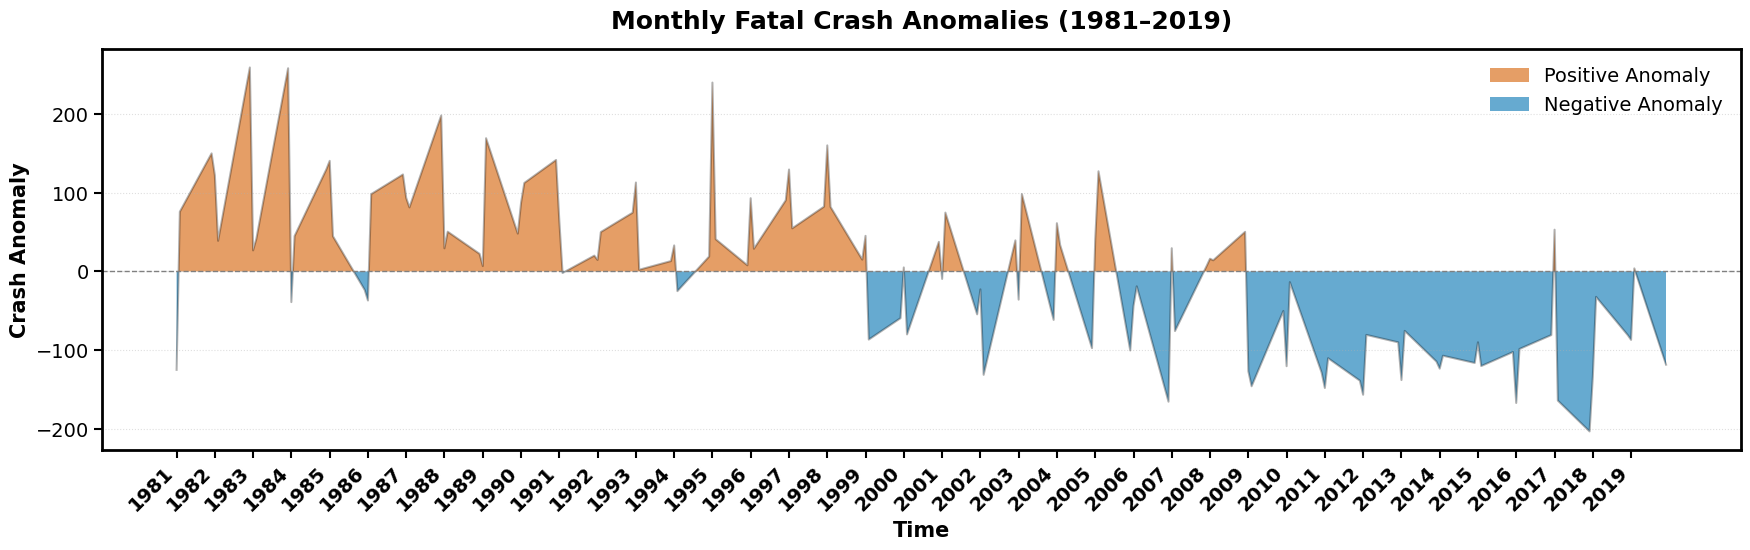

In [14]:
plot_crash_anomalies(monthly_summary,col_sel='ANOM_CRASH_COUNTS')

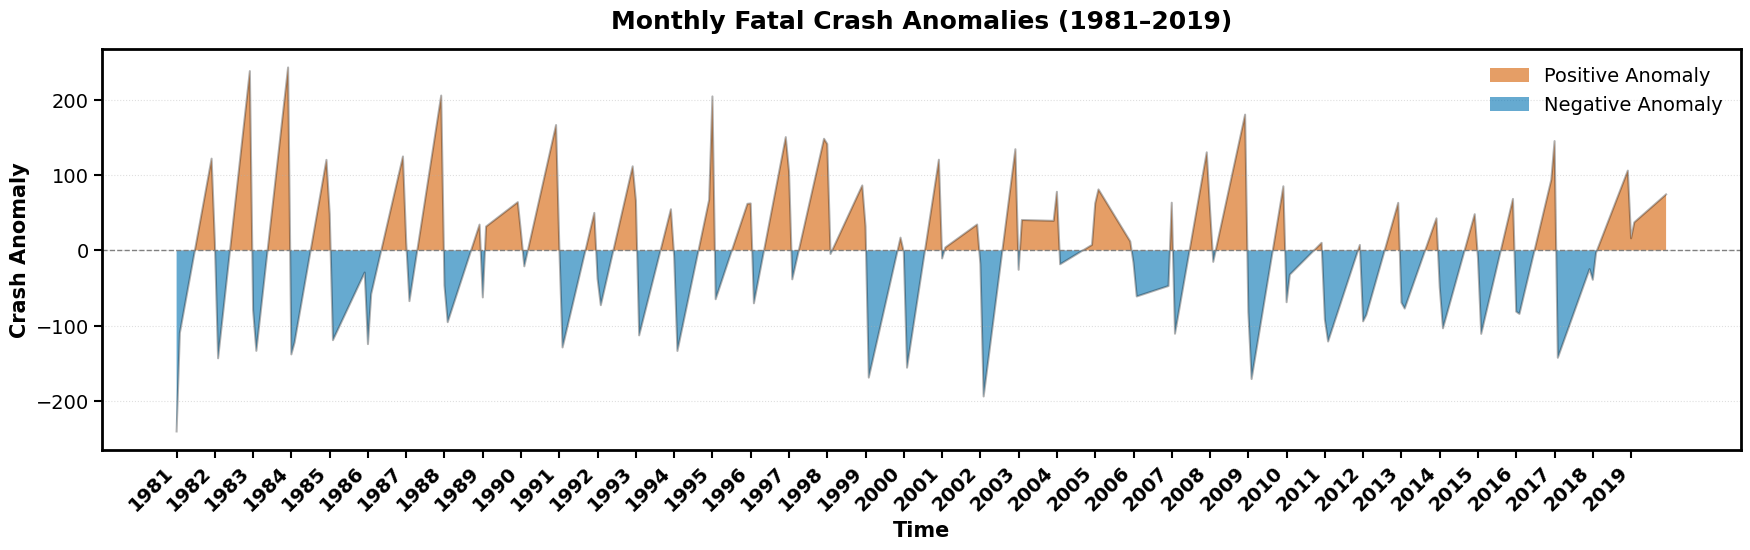

In [15]:
plot_crash_anomalies(monthly_summary,col_sel='DETRENDED_CRASH_COUNTS')

## Figure 5 Nino3.4

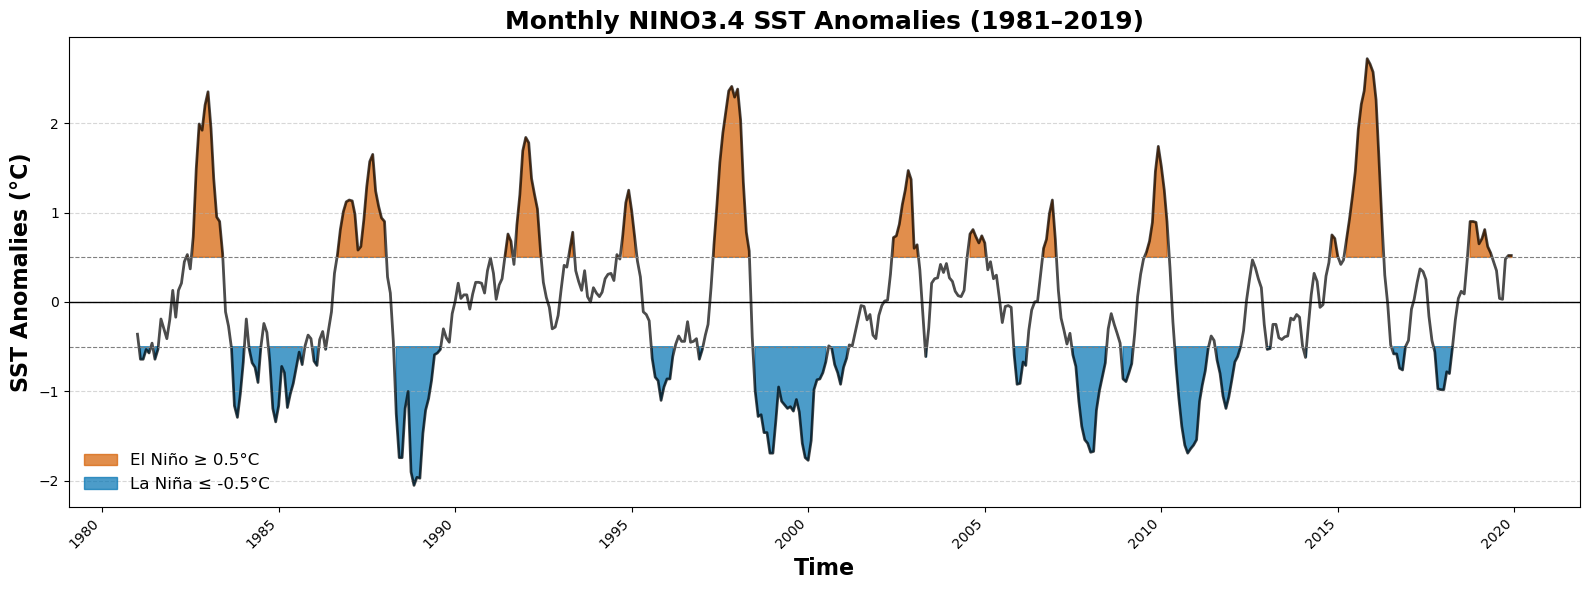

In [16]:
plot_nino34(df_combined,col_sel='SST_VALUE')

# Select only Dec-Jan-Feb from monthly_summary

In [17]:
monthly_summary_djf = monthly_summary[monthly_summary['MONTH'].isin([12, 1, 2])]

In [18]:
monthly_summary_djf.head()

,Unnamed: 0,STATE_ABBR,YEAR,MONTH,CRASH_COUNTS,ANOM_CRASH_COUNTS,DETRENDED_CRASH_COUNTS,PRECIP_ANOM_MEAN,PRECIP_ANOM_SUM,NINO34_SST_ANOM,DATE
0,0,AL,1981,1,4,-8.102564,-7.500721,-2.909368,-75399.174587,-0.36,1981-01-01
1,1,AL,1981,2,6,-4.512821,-5.502426,0.921696,32362.587778,-0.64,1981-02-01
2,2,AL,1981,12,10,-3.051282,-1.519082,0.591149,30640.421086,-0.20,1981-12-01
3,3,AL,1982,1,7,-5.102564,-4.520786,0.599387,23300.557964,0.13,1982-01-01
4,4,AL,1982,2,6,-4.512821,-5.522490,1.879957,55007.549538,-0.17,1982-02-01


## Figure 6: Nino34 Precip by State


KeyboardInterrupt



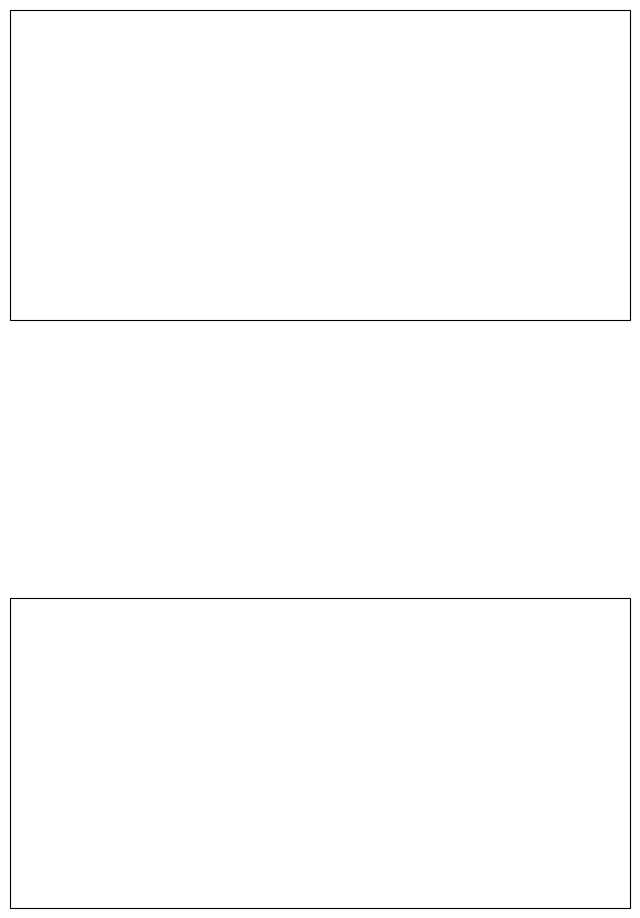

In [19]:
plot_state_precip_anomalies(monthly_summary, state_centers=state_centers)

## Figure 7: ENSO SWE Anomaly by State

## Figure 8

In [ ]:
cluster_zfile='../data/wxregimes/era5_cluster_comp_z_na_DJF1981-2019.nc'
ds_comp=xr.open_dataset(cluster_zfile)

plot_cluster_composites(ds_comp, cmap='RdBu_r', lon_0=260,
                        suptitle=None, 
                        nrows=2, ncols=2, 
                        levels=np.arange(-90, 100, 10),
                        dpi=300,
                        save_path="../figs/cluster_composites_djf.png")

## Figure 11

cluster_pfile='../data/wxregimes/era5_cluster_comp_p_na_DJF1981-2019.nc'
ds_pcomp=xr.open_dataset(cluster_pfile)
print(ds_pcomp)
plot_precip_cluster_composites(ds_pcomp,titles=ds_comp['names'].values)

In [ ]:
df_wxregimes_precip=pd.read_csv('../data/precip/state_precip_wxregimes.csv')
print(df_wxregimes_precip)
plot_wxregimes_state_precip_anomalies(df_wxregimes_precip,state_centers=state_centers)

# 4. Calculate Precip and FWRCA Rsquared

In [ ]:
# Precip anomalies vs crashes
r2_precip = compute_statewise_r2(monthly_summary, "PRECIP_ANOM_MEAN")

In [ ]:
plot_state_r2(r2_precip, state_centers=state_centers)

In [ ]:
r2_precip

## Figures 12 & 13

In [ ]:
plot_r2_map_panels(results_all, state_centers, filename_base="fwrca_r2")

## Figure 18

In [ ]:
# Load FARS crash data
# Assumes df_fars has: YEAR, MONTH, DAY, STATE (FIPS code)
# Load ds_cd (weather regime clusters) and ds_comp (regime names)
# Load states_map shapefile
states_map = gpd.read_file('../data/state_shape_file/cb_2018_us_state_20m.shp')
states_map['STATEFP'] = states_map['STATEFP'].astype(str).str.zfill(2)

In [ ]:
# 1. Add DATE and daily crash counts
df_fars['DATE'] = pd.to_datetime(df_fars[['YEAR', 'MONTH', 'DAY']], errors='coerce')
conus_daily = df_fars.groupby('DATE').size().reset_index(name='CRASH_COUNT')
conus_daily['DOY'] = conus_daily['DATE'].dt.dayofyear

# 2. Daily climatology and anomaly
climatology = conus_daily.groupby('DOY')['CRASH_COUNT'].mean().reset_index(name='CLIM_MEAN')
conus_daily = conus_daily.merge(climatology, on='DOY')
conus_daily['CRASH_ANOMALY'] = conus_daily['CRASH_COUNT'] - conus_daily['CLIM_MEAN']

# 3. Merge with regime labels (DJF only)
filtered_ds = ds_cd.sel(time=ds_cd['time.month'].isin([12, 1, 2]))
df_clusters = filtered_ds[['cluster']].to_dataframe().reset_index()
df_clusters.rename(columns={'time': 'DATE', 'cluster': 'REGIME'}, inplace=True)
df_clusters['DATE'] = pd.to_datetime(df_clusters['DATE'])
df_clusters['REGIME'] = df_clusters['REGIME'].astype(int)

merged = conus_daily.merge(df_clusters, on='DATE', how='inner')

# 4. Mean anomaly and CI
mean_anomaly_by_regime = merged.groupby('REGIME')['CRASH_ANOMALY'].mean()
counts_by_regime = merged.groupby('REGIME').size()
effective_n = (counts_by_regime / 28).astype(int)

ci = {}
for reg in mean_anomaly_by_regime.index:
    sample = merged.loc[merged['REGIME'] == reg, 'CRASH_ANOMALY']
    sem = sample.sem()
    dfree = effective_n[reg] - 1
    ci[reg] = stats.t.ppf(0.975, df=dfree) * sem if dfree > 0 else np.nan

regime_names = {i: str(name.values) for i, name in enumerate(ds_comp['names'])}
labels = [regime_names[r] for r in mean_anomaly_by_regime.index]

# 5. Plot bar chart
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#FFB3BA', '#BAE1FF', '#BFFCC6', '#FFFFBA']
ax.bar(
    labels, mean_anomaly_by_regime.values,
    yerr=[ci[r] for r in mean_anomaly_by_regime.index],
    color=colors[:len(labels)],
    edgecolor='black', capsize=8, linewidth=1.2
)
ax.axhline(0, color='gray', linestyle='--')
ax.set_ylabel('Mean Crash Anomaly')
ax.set_title('CONUS Crash Anomalies by Weather Regime (DJF)')
plt.tight_layout()
plt.show()


In [ ]:
pdf_colors = ['#0072B2', '#D55E00', '#009E73', '#CC79A7']
x_grid = np.linspace(merged['CRASH_ANOMALY'].min(), merged['CRASH_ANOMALY'].max(), 500)

plt.figure(figsize=(12, 7))
for i, reg in enumerate(sorted(merged['REGIME'].unique())):
    data = merged.loc[merged['REGIME'] == reg, 'CRASH_ANOMALY'].dropna()
    if len(data) < 2:
        continue
    pdf = gaussian_kde(data)(x_grid)
    pdf /= pdf.max()
    plt.plot(x_grid, pdf, label=regime_names[reg], color=pdf_colors[i], linewidth=2)
    plt.axvline(data.mean(), color=colors[i], linestyle='--', alpha=0.8)

# Plot overall
all_data = merged['CRASH_ANOMALY'].dropna()
pdf_all = gaussian_kde(all_data)(x_grid)
pdf_all /= pdf_all.max()
plt.plot(x_grid, pdf_all, color='gray', linewidth=3, label='All Regimes')
plt.axvline(all_data.mean(), color='black', linestyle='--', alpha=0.8)

plt.xlabel('Crash Anomaly')
plt.ylabel('Standardized Density')
plt.title('Standardized PDFs of Crash Anomalies by Weather Regime (DJF)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
# Compute anomalies
mean_by_regime_state = compute_statewise_regime_anomalies(df_fars, ds_cd, ds_comp)

# Merge with shapefile
gdf = states_map.merge(mean_by_regime_state, left_on='STATEFP', right_on='STATE', how='left')
gdf['ANOMALY'] = gdf['CRASH_ANOMALY']  # rename for compatibility
gdf['REGIME_LABEL'] = gdf['REGIME'].map(regime_names)

# Filter states_map and gdf to only include CONUS states
conus_fips = [f"{i:02d}" for i in range(1, 57) if i not in {2, 15}]  # 01–56, excluding AK (02) and HI (15)
gdf_conus = gdf[gdf['STATEFP'].isin(conus_fips)]

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

cmap_name = 'RdBu_r'
cmap = cm.get_cmap(cmap_name)

# Color normalization based on anomaly extremes
abs_max = max(abs(gdf_conus['ANOMALY'].min()), abs(gdf_conus['ANOMALY'].max()))
norm = colors.Normalize(vmin=-abs_max, vmax=abs_max)

subplot_labels = ['(a)', '(b)', '(c)', '(d)']
regimes_sorted = sorted(gdf_conus['REGIME'].dropna().unique())

# Get CONUS bounding box to fix axis limits
minx, miny, maxx, maxy = gdf_conus.total_bounds

for i, (regime, ax) in enumerate(zip(regimes_sorted, axes.flatten())):
    subset = gdf_conus[gdf_conus['REGIME'] == regime]

    # Plot choropleth
    subset.plot(
        column='ANOMALY',
        cmap=cmap_name,
        norm=norm,
        linewidth=0.8,
        edgecolor='black',
        ax=ax,
        legend=False,
    )

    # Fix map extent and aspect
    ax.set_xlim(minx, maxx)
    ax.set_ylim(miny, maxy)
    ax.set_aspect('equal')
    ax.margins(0)

    # Add numeric labels inside each state
    for idx, row in subset.iterrows():
        if row['geometry'].is_empty or pd.isna(row['ANOMALY']):
            continue
        x, y = row['geometry'].centroid.coords[0]

        ax.text(
            x, y,
            f"{row['ANOMALY']:.2f}",  # Show anomaly value with 2 decimal places
            ha='center',
            va='center',
            fontsize=10,
            fontweight='bold',
            color='black',
            clip_on=False,
            path_effects=[path_effects.withStroke(linewidth=2, foreground='white')]
        )

    label = regime_names.get(regime, f'Regime {regime}')
    ax.set_title(f"{subplot_labels[i]} {label}", loc='left', fontsize=14)

    ax.set_xticks([])
    ax.set_yticks([])

# Create ScalarMappable for colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm._A = []

# Add colorbar axis below the plots
cbar_ax = fig.add_axes([0.15, 0.05, 0.7, 0.03])  # left, bottom, width, height in figure coords

cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Average Anomalous Fatal Crashes per Day')

fig.suptitle('Average Anomalous Fatal Crashes by State and Weather Regime (DJF)', fontsize=18, y=0.95)

plt.tight_layout(rect=[0, 0.1, 1, 0.95])  # Leave space at bottom for colorbar
plt.show()

In [ ]:
# states_map already loaded
gdf_reg0 = compute_statewise_precip_averages(ds_chirps['precip'], states_map, regime_number=0)

# for all regimes
gdf_all = []
for reg in range(chirps_da.shape[0]):
    gdf = compute_statewise_precip_averages(chirps_da, states_map, regime_number=reg)
    gdf_all.append(gdf)

gdf_precip = pd.concat(gdf_all, ignore_index=True)
plot_statewise_precip_anomalies(gdf_precip=mean_precip_anom_by_state, regime_names=regime_names)